# Comprehensive Multi-Dataset Exploratory Data Analysis (EDA)

This notebook performs a systematic EDA across all four NYC TLC dataset categories:
1. **Yellow Taxi**
2. **Green Taxi**
3. **For-Hire Vehicle (FHV)**
4. **High Volume For-Hire Vehicle (FHVHV - Uber/Lyft)**

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configure Polars for better visibility
pl.Config.set_tbl_cols(30)
pl.Config.set_tbl_rows(10)

polars.config.Config

In [2]:
def run_full_eda(file_path, category):
    print(f"\n{'='*20} ANALYZING: {category.upper()} {'='*20}")
    
    # Load data
    df = pl.read_parquet(file_path)
    
    # 1. Standardize core columns (Keyword-based mapping)
    # Convert all column names to lowercase to handle inconsistent naming
    df = df.rename({col: col.lower() for col in df.columns})
    
    col_map = {}
    for col in df.columns:
        # Identify Pickup columns
        if "pickup" in col and ("time" in col or "date" in col):
            col_map[col] = "pickup_time"
        
        # Identify Dropoff columns
        if "dropoff" in col and ("time" in col or "date" in col):
            col_map[col] = "dropoff_time"
            
        # Identify other key columns
        if col in ["trip_distance", "trip_miles"]: col_map[col] = "distance"
        if col in ["fare_amount", "base_passenger_fare"]: col_map[col] = "fare"
        if "pulocation" in col: col_map[col] = "pulocationid"
        if "dolocation" in col: col_map[col] = "dolocationid"
    
    # Rename only if the name is different and exists in the current dataframe
    actual_map = {old: new for old, new in col_map.items() if old != new and old in df.columns}
    df_std = df.rename(actual_map)
    
    print(f"Standardized Columns: {df_std.columns}")
    
    # 2. Basic Statistics
    print("\n--- Statistical Summary ---")
    print(df_std.describe())
    
    # 3. Missing Values
    print("\n--- Null Counts ---")
    print(df_std.null_count())
    
    # 4. Temporal Analysis
    # Ensure pickup_time exists before proceeding
    if "pickup_time" in df_std.columns:
        # Handle potential data type issues (cast to datetime if needed)
        # Polars usually handles this, but we extract hour for demand patterns
        df_std = df_std.with_columns(pl.col("pickup_time").dt.hour().alias("hour"))
        
        if "dropoff_time" in df_std.columns:
            df_std = df_std.with_columns([
                ((pl.col("dropoff_time") - pl.col("pickup_time")).dt.total_seconds() / 60).alias("duration_min")
            ])
            print(f"\nDuration Stats (Min): {df_std['duration_min'].min()} | (Max): {df_std['duration_min'].max()}")
    
    # 5. Visualizations
    if "hour" in df_std.columns:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        
        # A. Hourly Demand Pattern
        hourly_demand = df_std.group_by("hour").agg(pl.count().alias("trips")).sort("hour")
        sns.lineplot(data=hourly_demand.to_pandas(), x="hour", y="trips", marker='o', ax=axes[0], color='blue')
        axes[0].set_title(f"{category.capitalize()} - Hourly Demand Pattern")
        axes[0].grid(True, alpha=0.3)
        
        # B. Distance Distribution (if available)
        if "distance" in df_std.columns:
            # Filter out extreme outliers for better visualization
            dist_data = df_std.filter((pl.col("distance") > 0) & (pl.col("distance") < 50)).select("distance").to_pandas()
            if not dist_data.empty:
                sns.boxplot(data=dist_data, x="distance", ax=axes[1], color='green')
                axes[1].set_title(f"{category.capitalize()} - Trip Distance (0-50 miles)")
            else:
                axes[1].text(0.5, 0.5, "No valid distance data (0-50 miles)", ha='center')
        else:
            axes[1].text(0.5, 0.5, "Distance column not available", ha='center')
            
        plt.tight_layout()
        plt.show()
    
    return df_std


==================== ANALYZING: YELLOW ====================
Standardized Columns: ['vendorid', 'pickup_time', 'dropoff_time', 'passenger_count', 'distance', 'ratecodeid', 'store_and_fwd_flag', 'pulocationid', 'dolocationid', 'payment_type', 'fare', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'cbd_congestion_fee']

--- Statistical Summary ---
shape: (9, 21)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ sta ┆ ven ┆ pic ┆ dro ┆ pas ┆ dis ┆ rat ┆ sto ┆ pul ┆ dol ┆ pay ┆ far ┆ ext ┆ mta ┆ tip ┆ tol ┆ imp ┆ tot ┆ con ┆ air ┆ cbd │
│ tis ┆ dor ┆ kup ┆ pof ┆ sen ┆ tan ┆ eco ┆ re_ ┆ oca ┆ oca ┆ men ┆ e   ┆ ra  ┆ _ta ┆ _am ┆ ls_ ┆ rov ┆ al_ ┆ ges ┆ por ┆ _co │
│ tic ┆ id  ┆ _ti ┆ f_t ┆ ger ┆ ce  ┆ dei ┆ and ┆ tio ┆ tio ┆ t_t ┆ --- ┆ --- ┆ x   ┆ oun ┆ amo ┆ eme ┆ amo ┆ tio ┆ t_f ┆ nge │
│ --- ┆ --- ┆ me  ┆ ime ┆ _co ┆ --- ┆ d   

C:\Users\tanba\AppData\Local\Temp\ipykernel_12484\1418988744.py:59: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  hourly_demand = df_std.group_by("hour").agg(pl.count().alias("trips")).sort("hour")


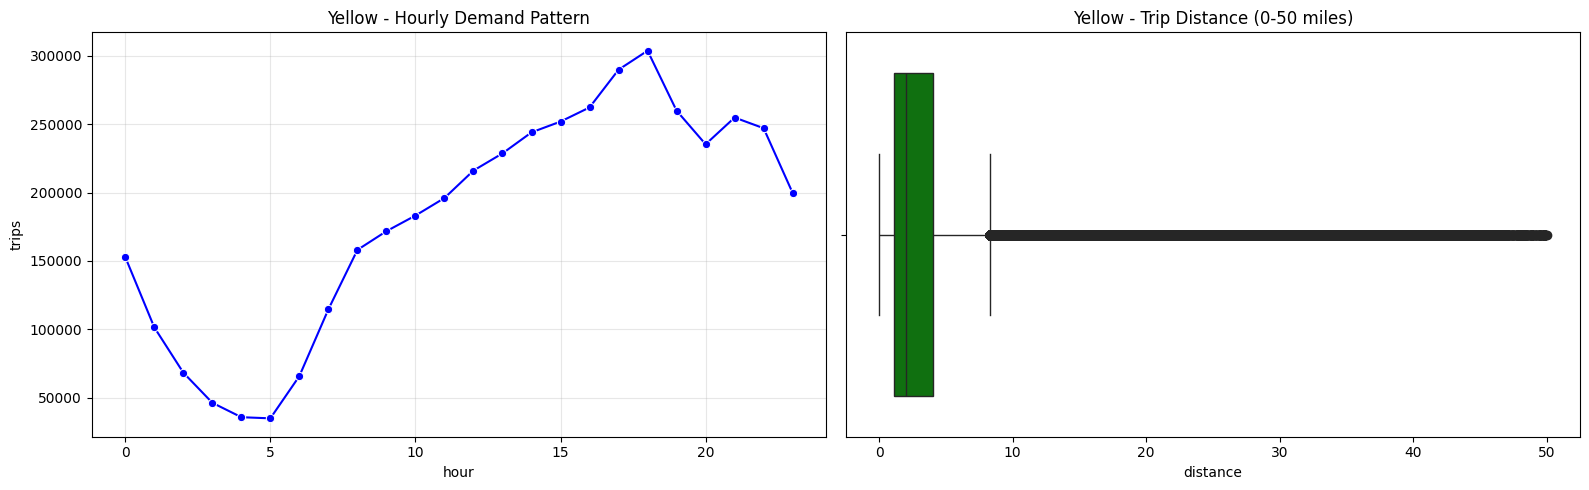


==================== ANALYZING: GREEN ====================
Standardized Columns: ['vendorid', 'pickup_time', 'dropoff_time', 'store_and_fwd_flag', 'ratecodeid', 'pulocationid', 'dolocationid', 'passenger_count', 'distance', 'fare', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'ehail_fee', 'improvement_surcharge', 'total_amount', 'payment_type', 'trip_type', 'congestion_surcharge', 'cbd_congestion_fee']

--- Statistical Summary ---
shape: (9, 22)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ sta ┆ ven ┆ pic ┆ dro ┆ sto ┆ rat ┆ pul ┆ dol ┆ pas ┆ dis ┆ far ┆ ext ┆ mta ┆ tip ┆ tol ┆ eha ┆ imp ┆ tot ┆ pay ┆ tri ┆ con ┆ cbd │
│ tis ┆ dor ┆ kup ┆ pof ┆ re_ ┆ eco ┆ oca ┆ oca ┆ sen ┆ tan ┆ e   ┆ ra  ┆ _ta ┆ _am ┆ ls_ ┆ il_ ┆ rov ┆ al_ ┆ men ┆ p_t ┆ ges ┆ _co │
│ tic ┆ id  ┆ _ti ┆ f_t ┆ and ┆ dei ┆ tio ┆ tio ┆ ger ┆ ce  ┆ --- ┆ --- ┆ x   ┆ oun ┆ amo ┆ fee ┆ eme ┆ amo ┆ t_t ┆ ype ┆ tio ┆ nge │
│ --- ┆ 

C:\Users\tanba\AppData\Local\Temp\ipykernel_12484\1418988744.py:59: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  hourly_demand = df_std.group_by("hour").agg(pl.count().alias("trips")).sort("hour")


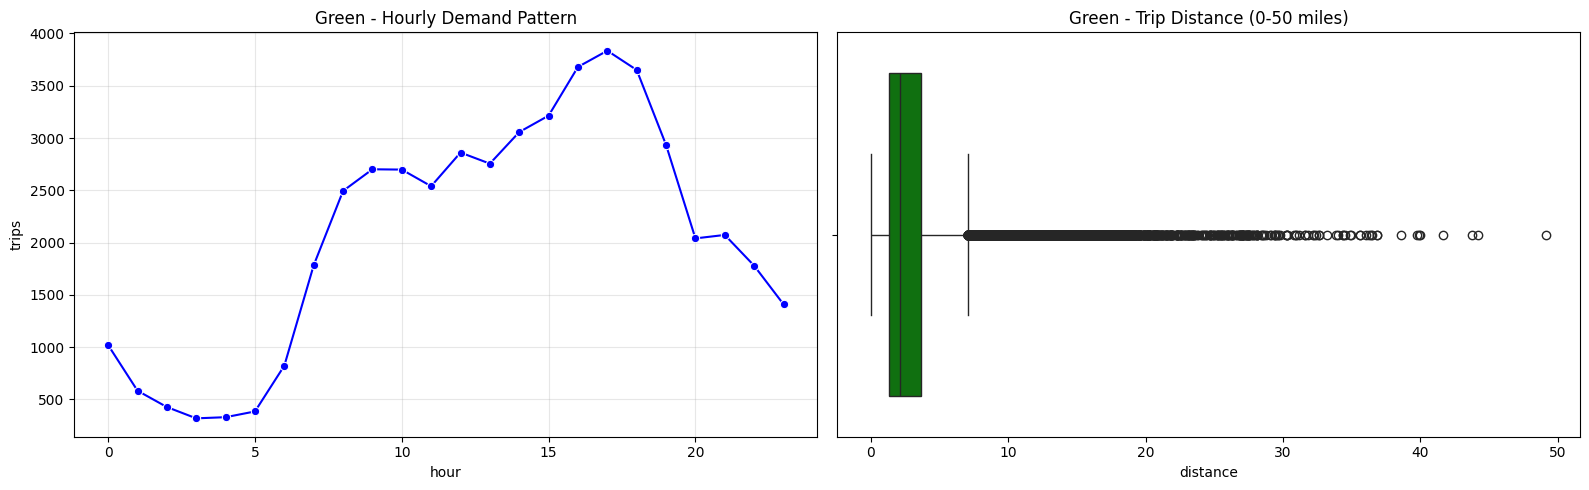


==================== ANALYZING: FHV ====================
Standardized Columns: ['dispatching_base_num', 'pickup_time', 'dropoff_time', 'pulocationid', 'dolocationid', 'sr_flag', 'affiliated_base_number']

--- Statistical Summary ---
shape: (9, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ statistic  ┆ dispatchin ┆ pickup_tim ┆ dropoff_t ┆ pulocatio ┆ dolocatio ┆ sr_flag   ┆ affiliate │
│ ---        ┆ g_base_num ┆ e          ┆ ime       ┆ nid       ┆ nid       ┆ ---       ┆ d_base_nu │
│ str        ┆ ---        ┆ ---        ┆ ---       ┆ ---       ┆ ---       ┆ f64       ┆ mber      │
│            ┆ str        ┆ str        ┆ str       ┆ f64       ┆ f64       ┆           ┆ ---       │
│            ┆            ┆            ┆           ┆           ┆           ┆           ┆ str       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ count      ┆ 2231731    ┆ 2231731    ┆ 2231

C:\Users\tanba\AppData\Local\Temp\ipykernel_12484\1418988744.py:59: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  hourly_demand = df_std.group_by("hour").agg(pl.count().alias("trips")).sort("hour")


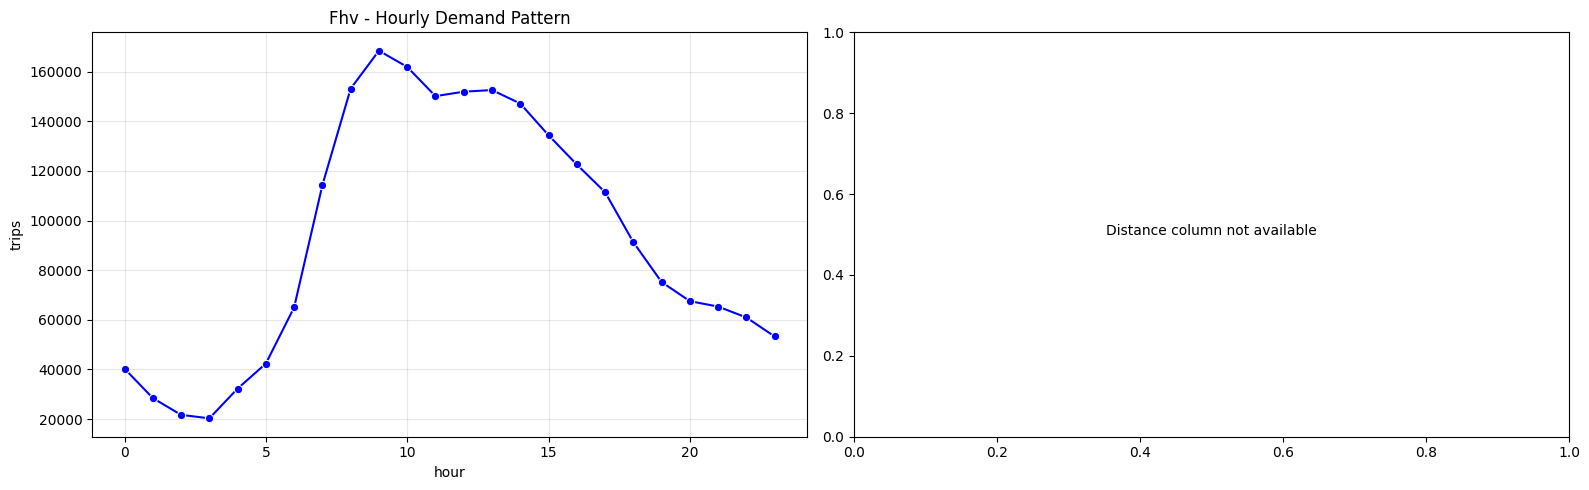


==================== ANALYZING: FHVHV ====================
Standardized Columns: ['hvfhs_license_num', 'dispatching_base_num', 'originating_base_num', 'request_datetime', 'on_scene_datetime', 'pickup_time', 'dropoff_time', 'pulocationid', 'dolocationid', 'distance', 'trip_time', 'fare', 'tolls', 'bcf', 'sales_tax', 'congestion_surcharge', 'airport_fee', 'tips', 'driver_pay', 'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag', 'wav_request_flag', 'wav_match_flag', 'cbd_congestion_fee']

--- Statistical Summary ---
shape: (9, 26)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ sta ┆ hvf ┆ dis ┆ ori ┆ req ┆ on_ ┆ pic ┆ dro ┆ pul ┆ dol ┆ dis ┆ tri ┆ far ┆ tol ┆ bcf ┆ sal ┆ con ┆ air ┆ tip ┆ dri ┆ sha ┆ sha ┆ acc ┆ wav ┆ wav ┆ cbd │
│ tis ┆ hs_ ┆ pat ┆ gin ┆ ues ┆ sce ┆ kup ┆ pof ┆ oca ┆ oca ┆ tan ┆ p_t ┆ e   ┆ ls  ┆ --- ┆ es_ ┆ ges ┆ por ┆ s   ┆ ver ┆ red ┆ red ┆ e

C:\Users\tanba\AppData\Local\Temp\ipykernel_12484\1418988744.py:59: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  hourly_demand = df_std.group_by("hour").agg(pl.count().alias("trips")).sort("hour")


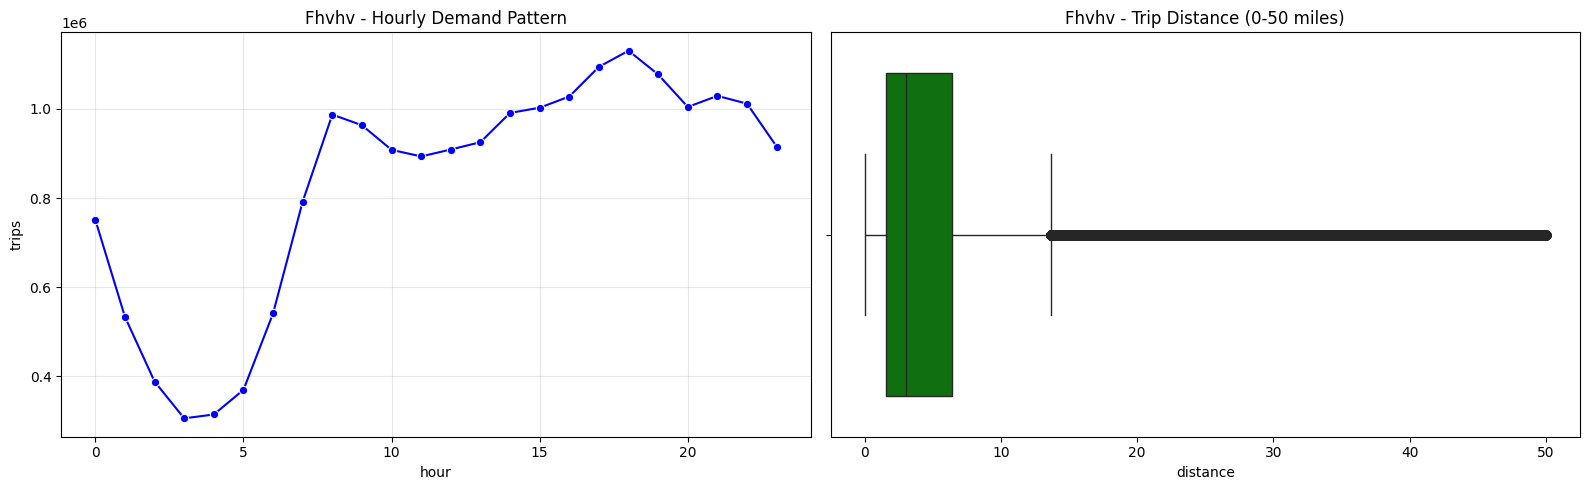

In [3]:
# Execute EDA for all 4 dataset types for June 2025
sample_files = {
    "yellow": "../dataset/Trip_Record/yellow/yellow_tripdata_2025-06.parquet",
    "green": "../dataset/Trip_Record/green/green_tripdata_2025-06.parquet",
    "fhv": "../dataset/Trip_Record/fhv/fhv_tripdata_2025-06.parquet",
    "fhvhv": "../dataset/Trip_Record/fhvhv/fhvhv_tripdata_2025-06.parquet"
}

for category, path in sample_files.items():
    try:
        run_full_eda(path, category)
    except Exception as e:
        print(f"Error processing {category}: {e}")

## Null-Cluster Heatmap (Cross-Dataset Diagnostic)

The next two cells extend the per-dataset EDA above with a **cross-dataset null
diagnostic** that powers the figure
[`visuals/null_clusters_heatmap.png`](../visuals/null_clusters_heatmap.png).

* **Panel A** — null share matrix (datasets × standardised fields). Highlights
  the 100 %-null "dead columns" (`ehail_fee` in Green) and the auxiliary-field
  null clusters described in `docs/EDA_Report.md`.
* **Panel B** — binarised null mask of a Yellow Taxi sample, sorted so the
  documented *Vendor-side logging failure* cluster (~121 294 rows) appears as a
  red band at the top.

Run the next cell to (re)compute the figure from the actual parquet files.
A standalone CLI version of the same logic lives at
`visuals/sources/generate_null_heatmap.py` and is what the report uses.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# Make the standalone helper importable so the notebook stays in sync
# with the artefact generator used by the report.
sys.path.insert(0, str(Path("..") / "visuals" / "sources"))
from generate_null_heatmap import (  # noqa: E402
    DOCUMENTED_NULL_RATES,
    STANDARD_COLUMNS,
    build_null_rate_dataframe,
    build_yellow_null_mask,
    compute_null_rates_from_disk,
    render,
)


# ---------------------------------------------------------------
# 1. Compute the null-rate matrix.
#    Falls back to documented EDA rates when raw parquet is absent.
# ---------------------------------------------------------------
rates = compute_null_rates_from_disk() or DOCUMENTED_NULL_RATES
rate_df = build_null_rate_dataframe(rates)

print("Null share (%) by dataset × column:")
display((rate_df * 100).round(2))


# ---------------------------------------------------------------
# 2. Inline preview of the heatmap, identical to the saved PNG.
# ---------------------------------------------------------------
output_path = Path("..") / "visuals" / "null_clusters_heatmap.png"
render(rates, output_path)
print(f"Saved: {output_path.resolve()}")

# Display inline for convenience.
from IPython.display import Image  # noqa: E402
Image(filename=str(output_path))